<a href="https://colab.research.google.com/github/alexander-toschev/cv-course/blob/main/ml/BasicBinary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
from keras.models import Sequential, Model
from keras.layers import Dense
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

In [21]:
# Generate synthetic data
X_train, y_train = make_classification(
    n_samples=1000,    # number of samples
    n_features=2,      # input_dim=2
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

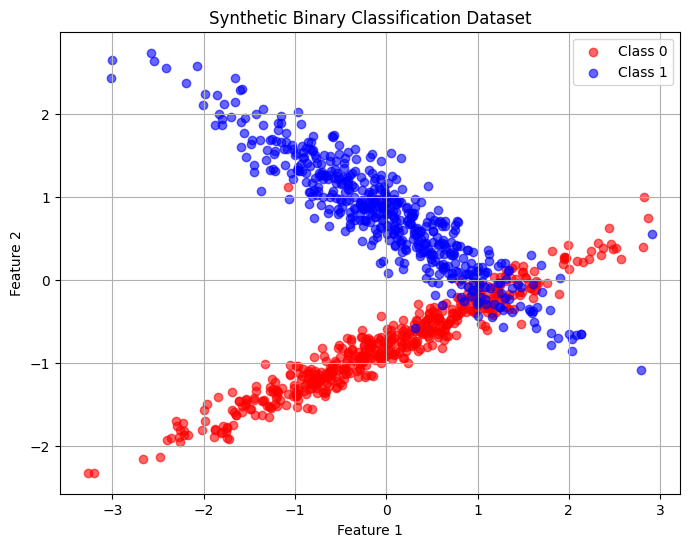

In [22]:
# Normalize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

# Plot the data
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], color='red', label='Class 0', alpha=0.6)
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color='blue', label='Class 1', alpha=0.6)
plt.title('Synthetic Binary Classification Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

# Convert to float32 for Keras
X_train = X_train.astype(np.float32)
y_train = y_train.astype(np.float32)

In [23]:
model = Sequential()
model.add(Dense(4, input_dim=2,activation='relu'))
model.add(Dense(6, activation='relu'))
model.add(Dense(6, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
# Compile and train model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=50, verbose=0)


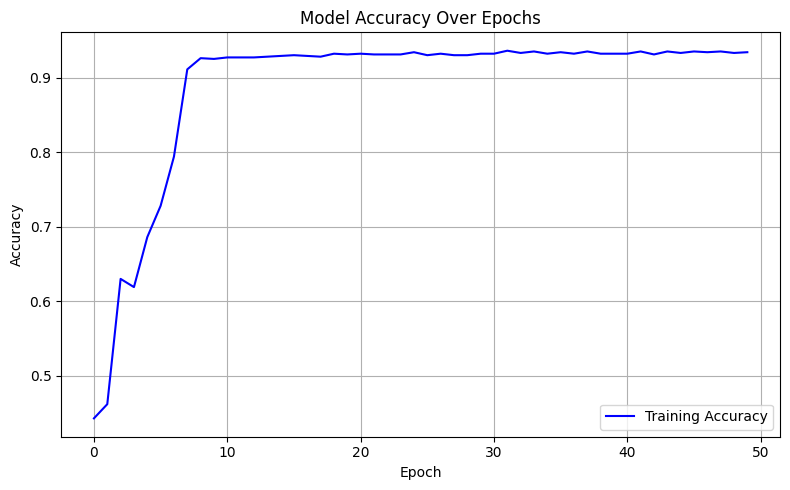

In [25]:


# Plot accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
# Function to plot intermediate outputs
def plot_intermediate_outputs(model, data_point):
    # Get the outputs of each layer
    layer_outputs = [layer.output for layer in model.layers]
    # The line below caused the error because the model has not been called yet to define its input
    # activation_model = Model(inputs=model.input, outputs=layer_outputs)

    # Call the model with a dummy input of the correct shape to initialize it
    #_ = model.predict(np.zeros((1, model.input_shape[1])))

    # Now creating the activation_model should work
    #activation_model = Model(inputs=model.input, outputs=layer_outputs)
    # Get the activations
    activations = model.predict(data_point.reshape(1, -1))

    # Plot the activations
    for i, activation in enumerate(activations):
        plt.figure(figsize=(6, 1))
        plt.title(f'Layer {i+1}: {model.layers[i].name}')
        plt.bar(range(len(activation[0])), activation[0])
        plt.grid(True)
        plt.tight_layout()
        plt.show()


Visualizing intermediate outputs for sample #0 (Class: 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


TypeError: object of type 'numpy.float32' has no len()

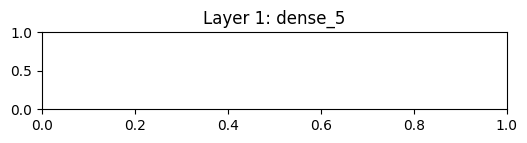

In [40]:
# Pick a few examples to visualize
for i in range(3):
    print(f"Visualizing intermediate outputs for sample #{i} (Class: {int(y_train[i])})")

    plot_intermediate_outputs(model, X_train[i])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Visualizing intermediate outputs for sample #0 (Class: 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


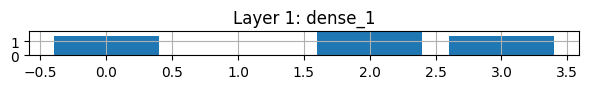

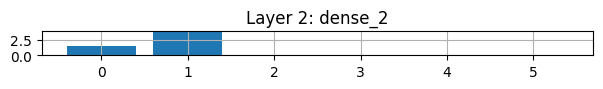

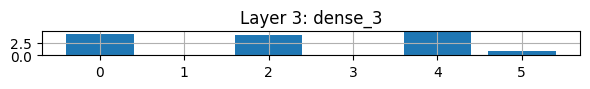

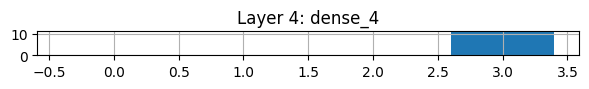

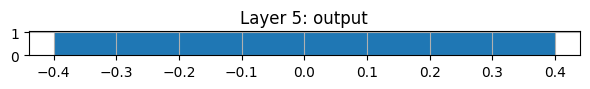

Visualizing intermediate outputs for sample #1 (Class: 0)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


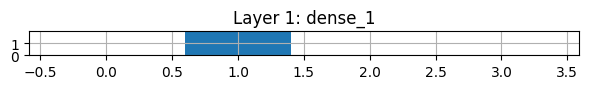

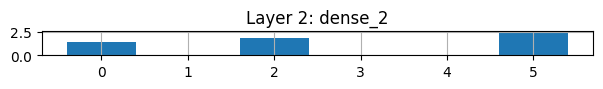

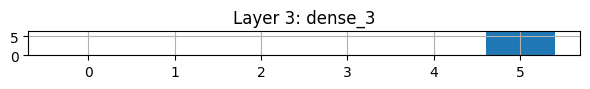

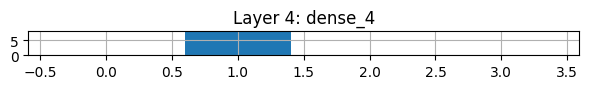

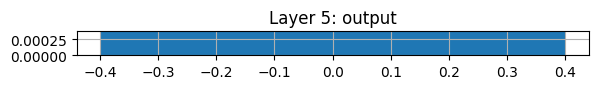

Visualizing intermediate outputs for sample #2 (Class: 0)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


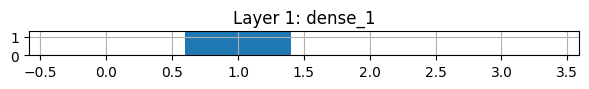

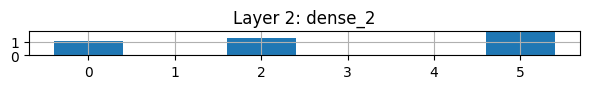

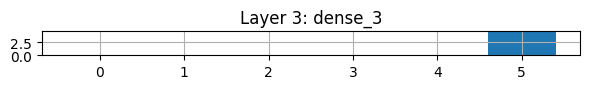

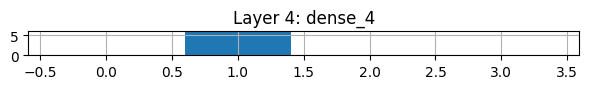

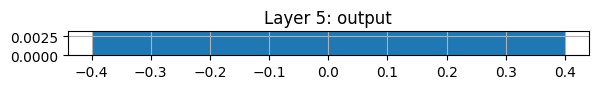

In [44]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential, Model
from keras.layers import Dense
import tensorflow as tf

# Generate and normalize the data
X_train, y_train = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_train = X_train.astype(np.float32)
y_train = y_train.astype(np.float32)

# Build the model
model = Sequential([
    Dense(4, input_dim=2, activation='relu', name='dense_1'),
    Dense(6, activation='relu', name='dense_2'),
    Dense(6, activation='relu', name='dense_3'),
    Dense(4, activation='relu', name='dense_4'),
    Dense(1, activation='sigmoid', name='output')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=50, verbose=0)

# Function to plot intermediate outputs
def plot_intermediate_outputs(model, data_point):
    # Get the outputs of each layer

    layer_outputs = [layer.output for layer in model.layers]

    # Create the activation model using the input layer of the original model
    # This change ensures the input shape is properly defined
    activation_model = Model(inputs=model.layers[0].input, outputs=layer_outputs)

    # Get the activations
    activations = activation_model.predict(data_point.reshape(1, -1))
    # Plot the activations
    for i, activation in enumerate(activations):
        plt.figure(figsize=(6, 1))
        plt.title(f'Layer {i+1}: {model.layers[i].name}')
        plt.bar(range(len(activation[0])), activation[0])
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Pick a few examples to visualize
for i in range(3):
    print(f"Visualizing intermediate outputs for sample #{i} (Class: {int(y_train[i])})")
    plot_intermediate_outputs(model, X_train[i])
